<a href="https://colab.research.google.com/github/mcarden4-netizen/Homework-Intro-to-ML/blob/Homework/Homework3Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
drive.mount('/content/drive')

filetest = '/content/drive/My Drive/diabetes.csv'
data = pd.DataFrame(pd.read_csv(filetest))
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [17]:
X = data.drop('Outcome', axis = 1)
Y = data['Outcome']

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, random_state=50, stratify=Y)

In [18]:
scaler = StandardScaler()
Xtrain = scaler.fit_transform(Xtrain)
Xtest = scaler.transform(Xtest)

In [19]:
Xtrain = np.c_[np.ones(Xtrain.shape[0]), Xtrain]
Xtest = np.c_[np.ones(Xtest.shape[0]), Xtest]

Ytrain = Ytrain.values
Ytest = Ytest.values

In [20]:
def sigmoid(z):

  z = np.clip(z, -500, 500)
  formula = 1 / (1 + np.exp(-z))

  return formula

In [21]:
def Calculate_loss(Input_data, Output_data, Theta):

  B = len(Output_data)

  predictions = sigmoid(Input_data.dot(Theta))

  eps = 1e-15

  predictions = np.clip(predictions, eps, 1 - eps)

  loss = -(1/B) * np.sum(Output_data * np.log(predictions) + (1 - Output_data) * np.log(1 - predictions))

  return loss

In [22]:
def gradient_descent(Input_data, Output_data, Theta, Alpha, instances):

  B = len(Output_data)

  loss_history = np.zeros(instances)
  accuracy_history = np.zeros(instances)

  for i in range(instances):

    predictions = sigmoid(Input_data.dot(Theta))

    errors = predictions - Output_data

    gradient = (1/B) * (Input_data.T.dot(errors))

    Theta -= Alpha * gradient

    loss_history[i] = Calculate_loss(Input_data, Output_data, Theta)

    training_pred = (sigmoid(Input_data.dot(Theta)) >= 0.5).astype(int)
    accuracy_history[i] = accuracy_score(Output_data, training_pred)

  return Theta, loss_history, accuracy_history

In [23]:
theta = np.zeros(Xtrain.shape[1])
alpha = .04
iterations = 2000

In [24]:
theta, loss_history, accuracy_history = gradient_descent(Xtrain, Ytrain, theta, alpha, iterations)

/tmp/ipykernel_817/1824866085.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


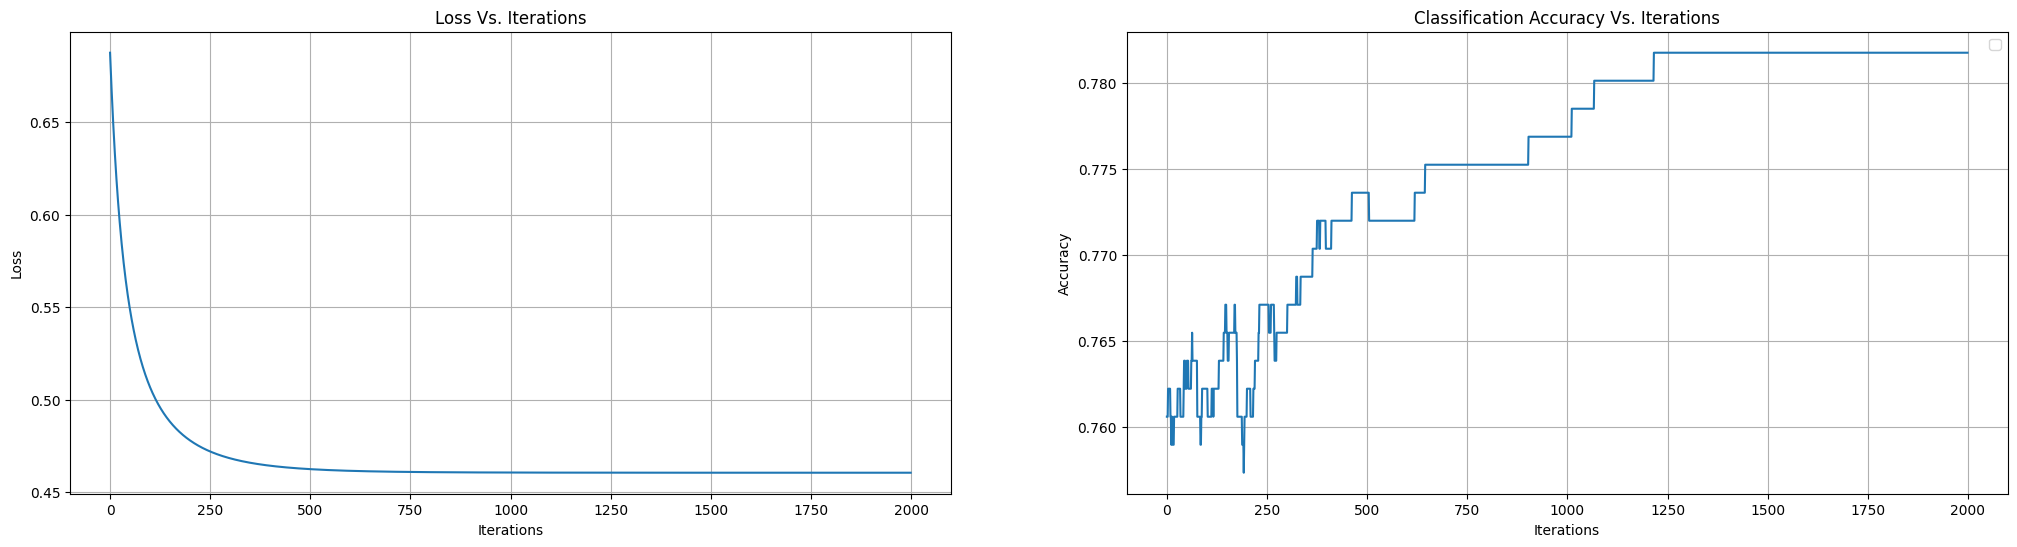

In [25]:
plt.figure(figsize=(25,6))

plt.subplot(1,2,1)
plt.plot(loss_history)
plt.grid(True)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss Vs. Iterations')

plt.subplot(1,2,2)
plt.plot(accuracy_history)
plt.grid(True)
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.title('Classification Accuracy Vs. Iterations')
plt.legend()

In [26]:
testp = sigmoid(Xtest.dot(theta))
Ypred = (testp >= 0.5).astype(int)

In [27]:
accuracy = accuracy_score(Ytest, Ypred)
precision = precision_score(Ytest, Ypred)
recall = recall_score(Ytest, Ypred)
f1 = f1_score(Ytest, Ypred)

In [28]:
print(f'Accuracy = {accuracy}')
print(f'Precision = {precision}')
print(f'Recall = {recall}')
print(f'F1 Score = {f1}')
print(f"Final training loss:", loss_history[-1])
print(f"Final training accuracy:", accuracy_history[-1])

Accuracy = 0.7532467532467533
Precision = 0.7222222222222222
Recall = 0.48148148148148145
F1 Score = 0.5777777777777777
Final training loss: 0.4605531741530214
Final training accuracy: 0.7817589576547231


In [29]:
Job = confusion_matrix(Ytest, Ypred)

print(Job)

[[90 10]
 [28 26]]


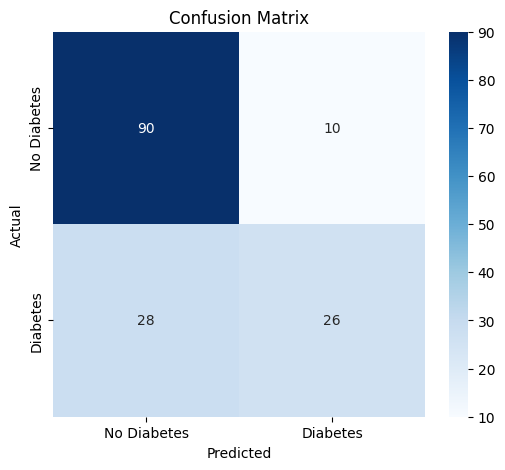

In [30]:
plt.figure(figsize=(6, 5))

sns.heatmap(Job, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()